# Effectuez une classification hiérarchique - Exemple avec le dataset Iris

# Preliminary

## 1.1 Context

Ce notebook est en lien le chapitre l'activité [Effectuez une classification hiérarchique](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees/5177936-effectuez-une-classification-hierarchique), de la partie 3 du cours  [Réalisez une analyse exploratoire de données](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees).

Nous allons travailler sur le jeu de données iris.


<br>

------------------------------

<br>

En cas de question, n'hésitez pas à nous adresser vos remarques ou suggestions via ce [lien](https://openclassrooms.zendesk.com/hc/fr/requests/new).

<br>

-------------------------

<br>

* version : 0.0.1
* last update:  2023-04-19

<br>

## 1.2 Imports

Importons les librairies :

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 1.3 Graphics

Chargeons les librairies graphiques :

In [2]:
sns.set()

## 1.4 Data

Chargeons les données. Nous utiliserons le dataframe iris, directement présent dans `scikit-learn`.

Il faudra travailler un peu pour pouvoir l'utiliser correctement. Ne pretez pas trop attention aux lignes ci dessous.

In [5]:
iris = datasets.load_iris()
df = pd.read_csv("df_final_2_acp.csv")
X=df.drop(columns=['Zone', 'iso3', 'Continent'])
X.head()

,population,evo_pop,Human Development Index,%_evo_idh,pop_unable_to_eat_healthy,%_evo_pop_unable_to_eat_healthy,cout_alim_saine,PIB,%_evo_pib,importation,%_evo_importation,Political polarization score,%_evo_politic,Access_Elec_Pct,%_evo_elec,LPI,%_evo_lpi,consommation_poulet,%_evo_consommation_poulet,dist
0,63212384.0,15.606770,0.741,5.106383,39000000.0,11.428571,1.00,3.777816e+05,-5.715917,312852.14,-2.137985,0.298,105.517241,87.7,0.029343,3.7,0.817439,2122618.28,9.182679,9353.5520
1,2811655.0,-3.298903,0.810,2.143758,300000.0,-57.142857,1.13,2.297767e+04,79.847536,47933.76,119.748590,-0.622,-59.319817,100.0,0.001001,2.5,-9.747292,64659.76,66.593049,1603.5340
2,46164219.0,20.174971,0.763,4.951857,9700000.0,24.358974,1.36,2.476262e+05,18.054948,28.06,1000.000000,-1.563,19.131098,100.0,0.008065,2.5,3.734440,421134.48,61.759281,1340.3900
3,84548231.0,4.326975,0.959,1.481481,1700000.0,-26.086957,0.66,4.525704e+06,18.844573,492941.64,43.314486,0.004,-100.164069,100.0,0.000000,4.1,1.736973,940232.90,5.574989,439.8984
4,36749906.0,40.451119,0.616,8.641975,26000000.0,41.304348,1.15,9.055216e+04,-33.763268,209561.94,-38.762897,-0.644,23.846154,51.1,0.330729,2.1,-7.894737,269798.32,-27.491892,6510.3220


# 2. About ACH

Effectuons une classification hiérarchique ascendante.

## 2.1 Compute linkage

Nous allons calculer les distances en spécifiant la méthode à utiliser:

In [6]:
Z = linkage(X, method="ward")
pd.DataFrame(Z)

,0,1,2,3
0,76.0,77.0,2.025277e+04,2.0
1,1.0,70.0,7.114811e+04,2.0
2,26.0,41.0,7.882250e+04,2.0
3,24.0,37.0,1.024334e+05,2.0
4,67.0,72.0,1.166647e+05,2.0
...,...,...,...,...
117,232.0,238.0,2.722363e+08,110.0
118,237.0,239.0,3.343868e+08,11.0
119,23.0,53.0,4.219232e+08,2.0
120,240.0,241.0,8.364872e+08,121.0


## 2.2 Dendrograms

Nous pouvons désormais afficher le dendrogramme:

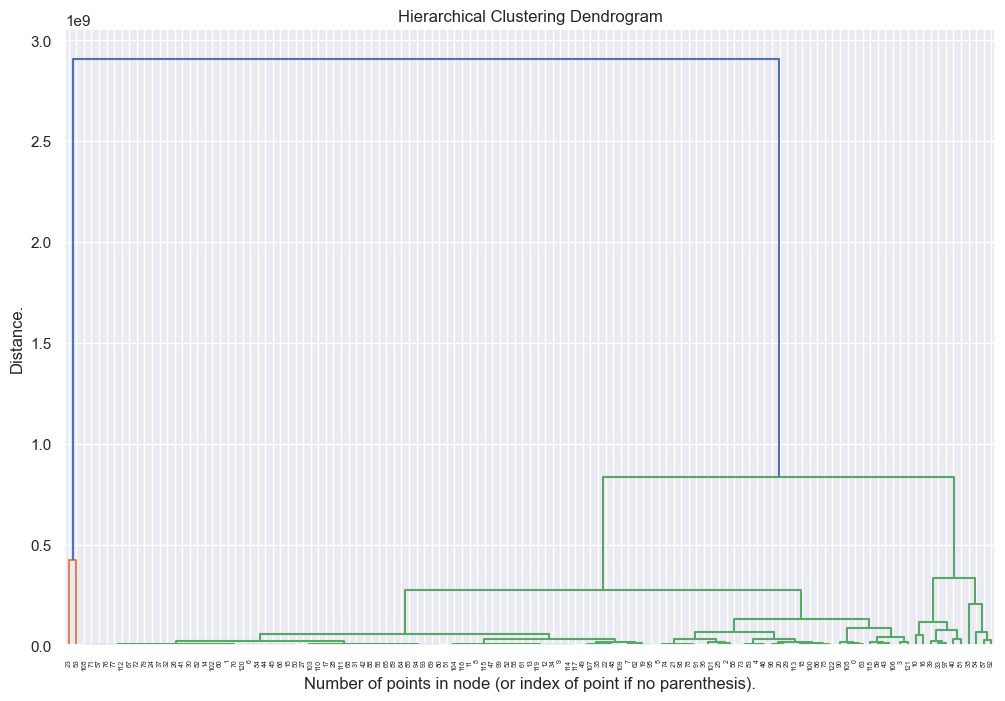

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, ax=ax)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance.")
plt.show()

Le dendrogramme semble pertinent mais sa profondeur le rend illisible.

On peut jouer sur différents paramètres pour obtenir un dendrogramme plus lisible :

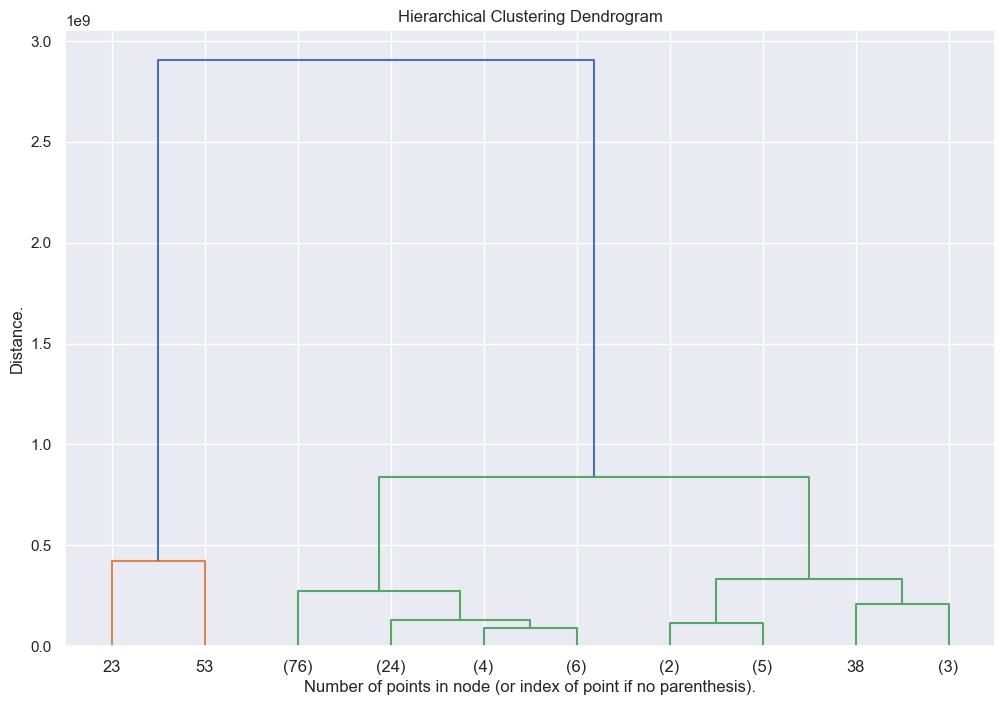

In [8]:
# les arguments p=10, truncate_mode="lastp" signifient que l'on ne va afficher que 10 clusters

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, p=10, truncate_mode="lastp", ax=ax)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance.")
plt.show()

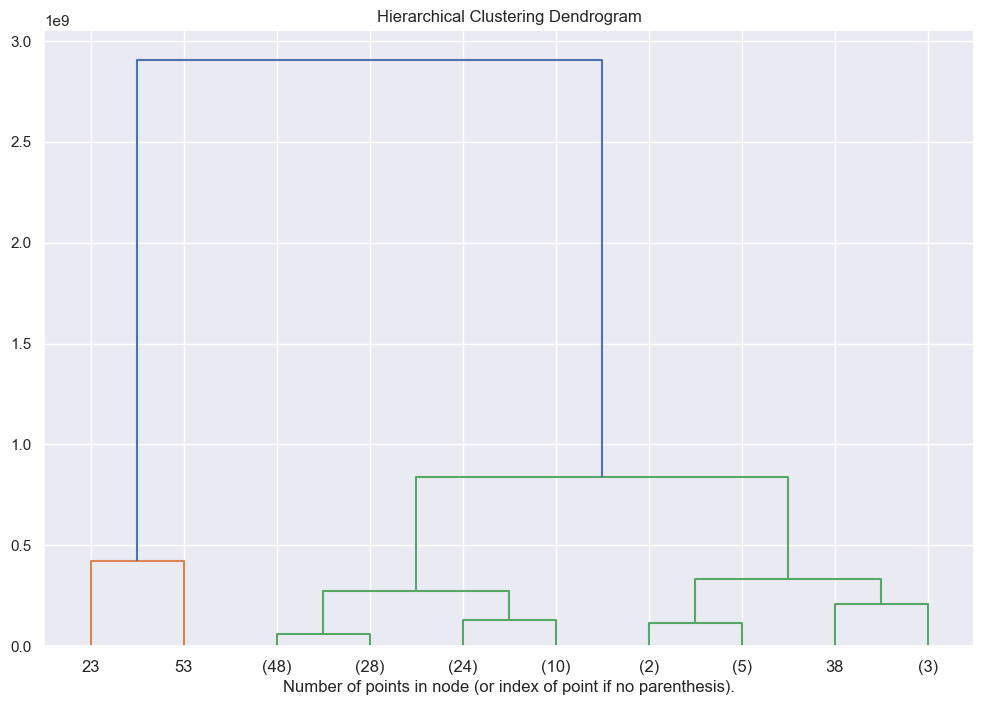

In [9]:
#  les arguments p=3, truncate_mode="level"signifient que l'on ne va afficher que les clusters issus de 3 noeuds.

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, p=3, truncate_mode="level", ax=ax)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

## 2.3 Clusters

Pour définir les clusters, on peut utiliser `scipy` ou `scikit-learn`.

### 2.3.1 Scikit-Learn

On instancie un estimateur :

In [10]:
cah = AgglomerativeClustering(n_clusters=3, linkage="ward")

On entraine l'estimateur :

In [11]:
cah.fit(X)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",3
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


Regardons nos clusters :

In [12]:
cah.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

-- **ATTENTION** --  
Ici, `0`,`1`,`2` est à considérer comme une variable catégorielle cardinale. Il n'y a pas d'ordre entre les clusters.

Le cluster `0` n'est pas *supérieur* au cluster `1` par exemple. Considérez que c'est plus un *id* qu'une *valeur*.






Pour être plus clair, nous allons utiliser des lettres plutôt que des nombres:


In [13]:
dd = {i:j for i,j in enumerate(list("abc"))}
labels = [dd[i] for i in cah.labels_]
labels[:10]

['c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c']

Disons que c'est plus clair maintenant...


Ajoutons nos labels à `X`

In [14]:
X["cluster"] = labels
X.head()

,population,evo_pop,Human Development Index,%_evo_idh,pop_unable_to_eat_healthy,%_evo_pop_unable_to_eat_healthy,cout_alim_saine,PIB,%_evo_pib,importation,...,Political polarization score,%_evo_politic,Access_Elec_Pct,%_evo_elec,LPI,%_evo_lpi,consommation_poulet,%_evo_consommation_poulet,dist,cluster
0,63212384.0,15.606770,0.741,5.106383,39000000.0,11.428571,1.00,3.777816e+05,-5.715917,312852.14,...,0.298,105.517241,87.7,0.029343,3.7,0.817439,2122618.28,9.182679,9353.5520,c
1,2811655.0,-3.298903,0.810,2.143758,300000.0,-57.142857,1.13,2.297767e+04,79.847536,47933.76,...,-0.622,-59.319817,100.0,0.001001,2.5,-9.747292,64659.76,66.593049,1603.5340,c
2,46164219.0,20.174971,0.763,4.951857,9700000.0,24.358974,1.36,2.476262e+05,18.054948,28.06,...,-1.563,19.131098,100.0,0.008065,2.5,3.734440,421134.48,61.759281,1340.3900,c
3,84548231.0,4.326975,0.959,1.481481,1700000.0,-26.086957,0.66,4.525704e+06,18.844573,492941.64,...,0.004,-100.164069,100.0,0.000000,4.1,1.736973,940232.90,5.574989,439.8984,c
4,36749906.0,40.451119,0.616,8.641975,26000000.0,41.304348,1.15,9.055216e+04,-33.763268,209561.94,...,-0.644,23.846154,51.1,0.330729,2.1,-7.894737,269798.32,-27.491892,6510.3220,c


Observons nos clusters:

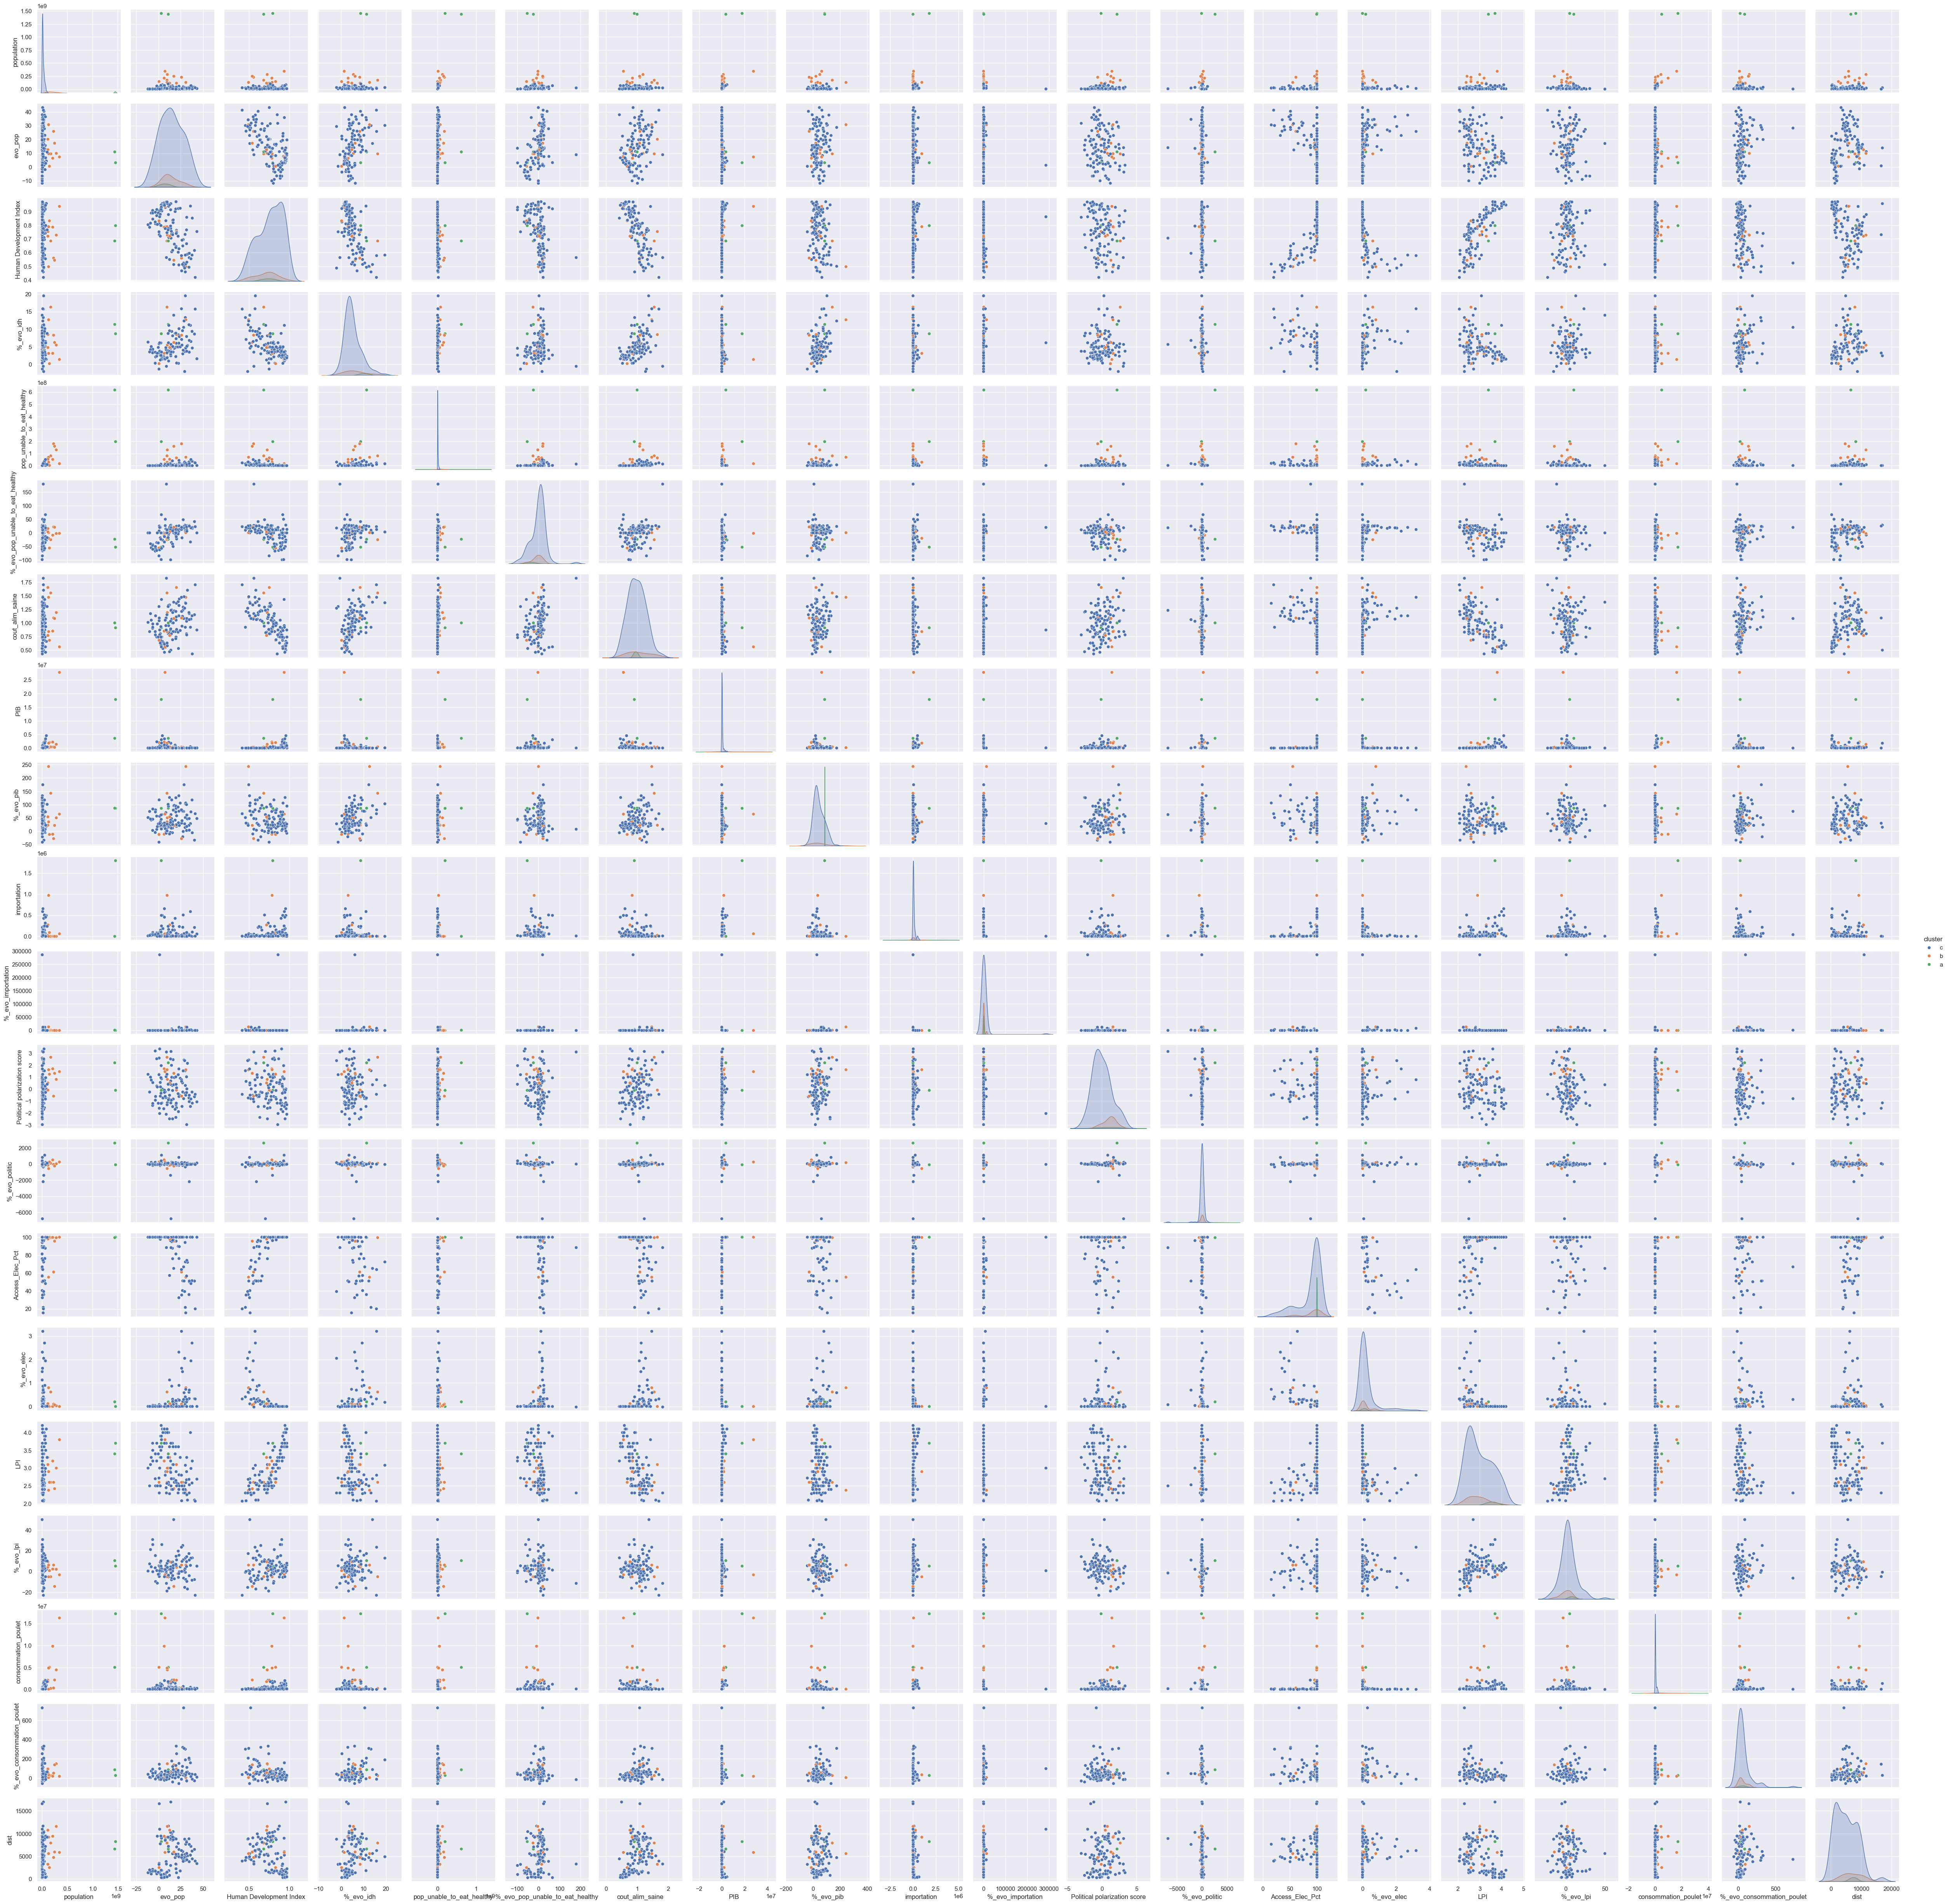

In [15]:
sns.pairplot(X, hue="cluster")

### 2.3.2 Scipy

Pour faire la même chose avec `scipy`, il suffit de prendre notre `Z` :

In [16]:
Z[:10]

array([[7.60000000e+01, 7.70000000e+01, 2.02527653e+04, 2.00000000e+00],
       [1.00000000e+00, 7.00000000e+01, 7.11481060e+04, 2.00000000e+00],
       [2.60000000e+01, 4.10000000e+01, 7.88225027e+04, 2.00000000e+00],
       [2.40000000e+01, 3.70000000e+01, 1.02433417e+05, 2.00000000e+00],
       [6.70000000e+01, 7.20000000e+01, 1.16664745e+05, 2.00000000e+00],
       [1.40000000e+01, 1.02000000e+02, 1.55342832e+05, 2.00000000e+00],
       [5.70000000e+01, 1.23000000e+02, 1.65346204e+05, 3.00000000e+00],
       [7.90000000e+01, 1.26000000e+02, 2.02595695e+05, 3.00000000e+00],
       [6.00000000e+00, 8.40000000e+01, 2.04515009e+05, 2.00000000e+00],
       [4.20000000e+01, 8.80000000e+01, 2.06873105e+05, 2.00000000e+00]])

Ensuite on défini le nombre de clusters que l'on souhaite:

In [17]:
k=3

On applique ensuite la fonction `fclusters`de `scipy`pour définir les clusters :

In [18]:
clusters = fcluster(Z, k, criterion='maxclust')
clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3,
       2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

Ensuite on peut faire les représentations graphiques comme avec `scikit-learn`!